In [1]:
#imports
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.hawkes_lob.simulator import simulate_lob, plot_simulation
from src.hawkes_lob.strategy  import (avellaneda_stoikov, plot_strategy, strategy_metrics)

Total trades simulated : 554
Buy trades             : 283
Sell trades            : 271


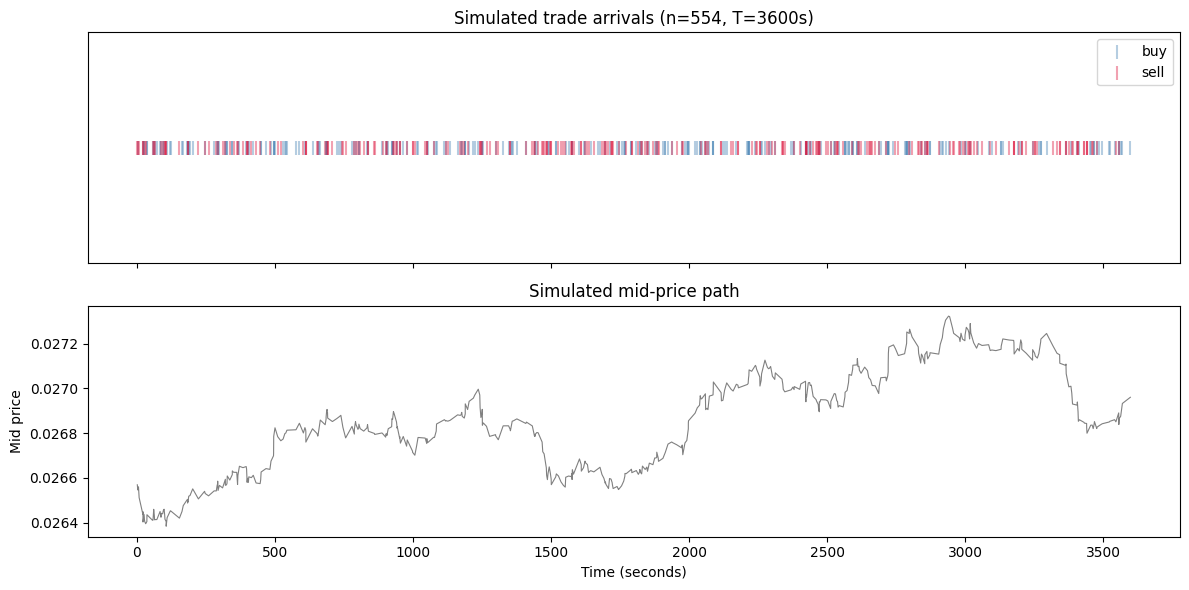

In [2]:
#simulate 1 hour of ETH/BTC
result = simulate_lob(T=3600.0, initial_price=0.0266,
                      initial_spread=0.0001, seed=42)

print(f"Total trades simulated : {len(result.states)}")
print(f"Buy trades             : {len(result.buy_times)}")
print(f"Sell trades            : {len(result.sell_times)}")

plot_simulation(result)

In [3]:
# Calibrate gamma, sigma, k for ETH/BTC
# mid price ~ 0.0266, market spread ~ 0.0001

# sigma: realized volatility from simulation
prices  = np.array([s.mid_price for s in result.states])
returns = np.diff(prices) / prices[:-1]
sigma_empirical = returns.std()
print(f"Empirical sigma : {sigma_empirical:.6f}")

# k: solve for k that gives target spread ~ 2x market spread
gamma         = 0.1
target_spread = 0.0002
k_calibrated  = gamma / (np.exp(gamma * target_spread / 2) - 1)
print(f"k calibrated    : {k_calibrated:.2f}")

Empirical sigma : 0.000960
k calibrated    : 9999.95



--- Strategy Metrics ---
final_pnl            : 0.0130
realized_pnl         : 0.0399
unrealized_pnl       : -0.0270
max_pnl              : 0.0130
min_pnl              : 0.0000
max_drawdown         : 0.0002
max_inventory        : 3.0000
sharpe               : 3.3353
sharpe_annualized    : 803.4426
n_steps              : 554.0000
n_fills              : 131.0000
n_fills_buy          : 65.0000
n_fills_sell         : 66.0000
fill_rate_pct        : 23.6462


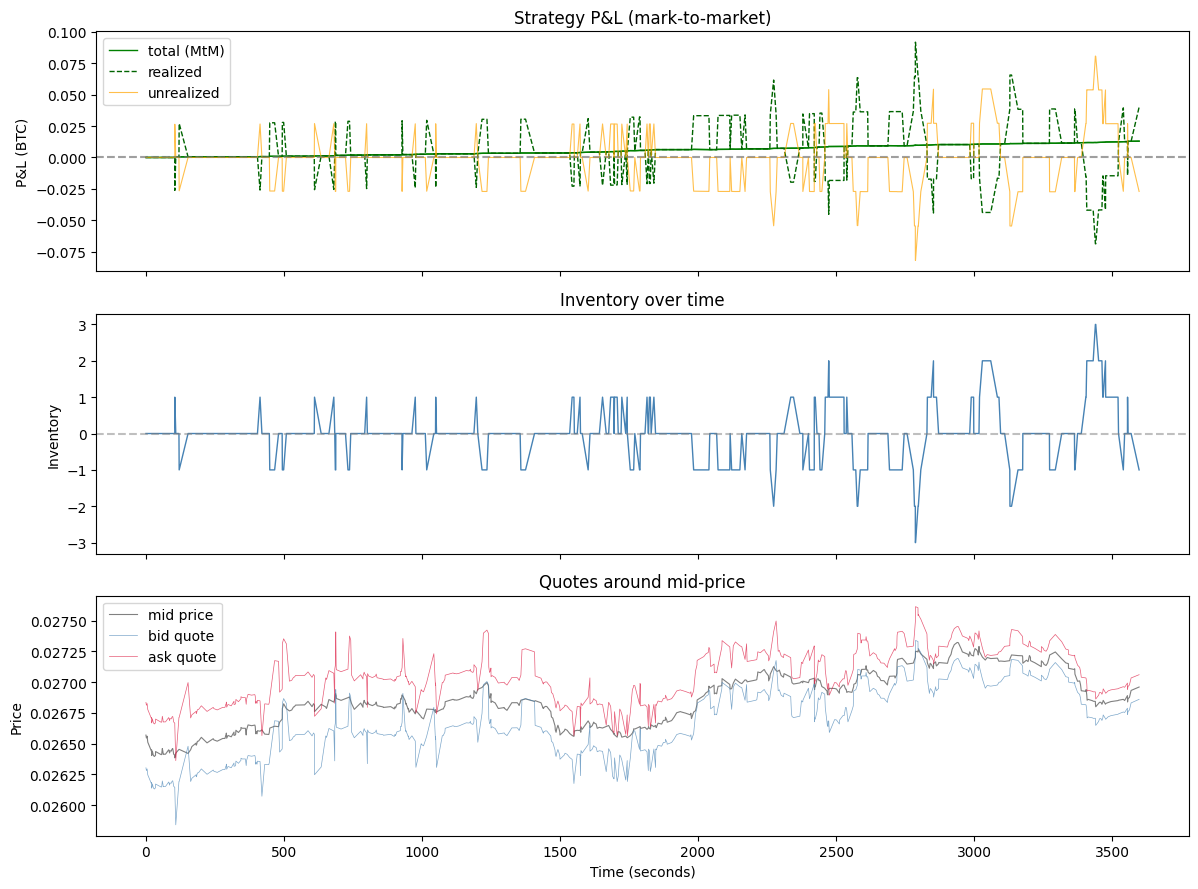

In [4]:
#run strategy
state = avellaneda_stoikov(result,
                           gamma=gamma,
                           sigma=sigma_empirical,
                           k=k_calibrated,
                           T=3600.0)
metrics = strategy_metrics(state)

print(f"\n--- Strategy Metrics ---")
for k, v in metrics.items():
    print(f"{k:20s} : {v:.4f}")

plot_strategy(state, result)